# Step 1 - Atmosphere field (MLP + Gaussian Fourier features)

Minimal check of `atmosphere_field.py`. The field maps normalized `(x,y,z) in [-1,1]` to the
physical atmosphere `(T, P, vz, Bx, By, Bz, vturb)`. We verify: output shapes/ranges, the
anchored warm start, and spatial + vertical smoothness (anisotropic Fourier bandwidth).

In [1]:
import os, sys
os.environ.setdefault('JAX_PLATFORMS', 'cpu')
sys.path.insert(0, os.path.abspath('..'))   # repo root (adora_precision)
sys.path.insert(0, os.path.abspath('.'))    # pinn/
%matplotlib inline
import numpy as np, jax, jax.numpy as jnp
import matplotlib.pyplot as plt
import atmosphere_field as af
key = jax.random.PRNGKey(0)
params = af.init_params(key)      # anchored: small head weights -> ~constant field at init
print('channels:', af.CHANNELS)

channels: ('T', 'P', 'vz', 'Bx', 'By', 'Bz', 'vturb')


### Forward pass on a grid: shapes, ranges, and the anchored start
At init the field should sit at the `DEFAULT_ANCHOR` (mid-photosphere) everywhere.

In [2]:
coords = af.grid_coords(16, 16, 50)
out = af.forward(params, coords)
print('coords', coords.shape)
for ch in af.CHANNELS:
    a = np.asarray(out[ch]); print(f'  {ch:5s} shape={a.shape} min={a.min():+.3e} max={a.max():+.3e}')

coords (12800, 3)
  T     shape=(12800,) min=+5.988e+03 max=+6.023e+03
  P     shape=(12800,) min=+9.590e+03 max=+1.026e+04
  vz    shape=(12800,) min=-4.873e+01 max=+6.183e+01
  Bx    shape=(12800,) min=-7.805e-04 max=+8.574e-04
  By    shape=(12800,) min=-3.210e-04 max=+7.555e-04
  Bz    shape=(12800,) min=-7.478e-04 max=+6.378e-04
  vturb shape=(12800,) min=+9.821e+02 max=+1.009e+03


### Vertical profiles: anchored vs a 'random' field
A field with larger head weights (`head_std=0.5`) shows the representable variation; the anchored
one is ~flat. This is just the untrained network - step 3 pretrains it to a real atmosphere.

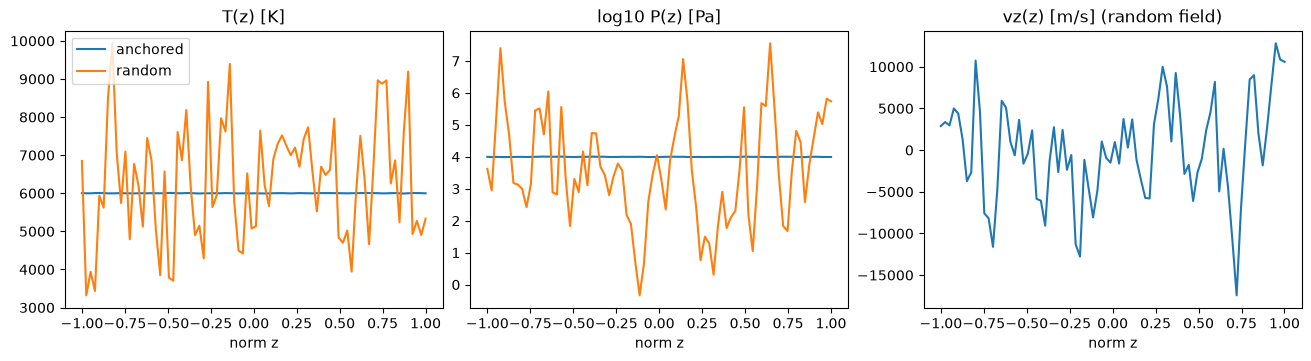

In [3]:
params_rnd = af.init_params(jax.random.PRNGKey(1), head_std=0.5)
z = jnp.linspace(-1, 1, 80)
col = lambda p: af.forward(p, jnp.stack([0.1*jnp.ones_like(z), -0.2*jnp.ones_like(z), z], -1))
oa, orr = col(params), col(params_rnd)
fig, ax = plt.subplots(1, 3, figsize=(13, 3.5), layout='constrained')
ax[0].plot(z, oa['T'], label='anchored'); ax[0].plot(z, orr['T'], label='random')
ax[0].set(title='T(z) [K]', xlabel='norm z'); ax[0].legend()
ax[1].plot(z, np.log10(oa['P'])); ax[1].plot(z, np.log10(orr['P']))
ax[1].set(title='log10 P(z) [Pa]', xlabel='norm z')
ax[2].plot(z, orr['vz']); ax[2].set(title='vz(z) [m/s] (random field)', xlabel='norm z')
plt.show()

### Horizontal map at fixed z: spatial smoothness / anisotropy
The Fourier bandwidth `sigmas=(x,y,z)` caps roughness; xy shares one bandwidth here.

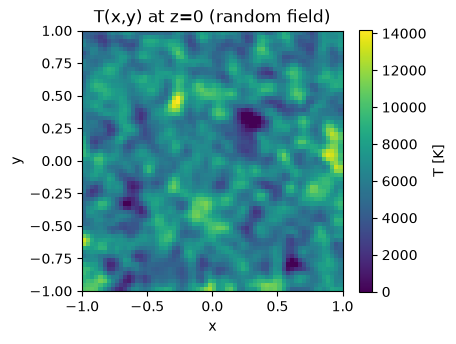

In [4]:
nx = ny = 64
xy = af.grid_coords(nx, ny, 1)[:, :2]
coords_xy = jnp.concatenate([xy, jnp.zeros((nx*ny, 1))], -1)   # z = 0 slice
Txy = np.asarray(af.forward(params_rnd, coords_xy)['T']).reshape(nx, ny)
plt.figure(figsize=(4.2, 3.4))
plt.imshow(Txy.T, origin='lower', extent=[-1, 1, -1, 1])
plt.colorbar(label='T [K]'); plt.title('T(x,y) at z=0 (random field)')
plt.xlabel('x'); plt.ylabel('y'); plt.show()